In [ ]:
import zipfile
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.feature_selection import f_classif # ANOVA F-test 
from sklearn.feature_selection import mutual_info_classif # Mutual Information
import xgboost as xgb # XGboost
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.svm import SVC # SVM

# ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2 as l2_reg
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import random

# XAI
from lime.lime_tabular import LimeTabularExplainer
import shap

c:\Users\Amal\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%pwd

'c:\\Users\\Amal\\Desktop\\Predict_Diabetes\\Predict_Diabetes\\notebook'

In [4]:
%cd ..

c:\Users\Amal\Desktop\Predict_Diabetes\Predict_Diabetes


using dhist requires you to install the `pickleshare` library.


Data ingestion

In [21]:
from utils.common import load_yaml_config

# Read config.yaml
config = load_yaml_config('yaml file/config.yaml')
config

{'artifacts_root': 'artifacts',
 'data_ingestion': {'local_data_file': 'dataset/Diabetes_Dataset.zip',
  'unzip_dir': 'artifacts/data_ingestion'},
 'data_validation': {'unzip_data_dir': 'artifacts/data_ingestion/diabetes_dataset.csv'},
 'data_transformation': {'list_feature_drop_file': 'artifacts/data_feature_reduction/list_feature_drop.txt'},
 'model_trainer': {'train_data_path': 'artifacts/model_trainer/train.csv',
  'test_data_path': 'artifacts/model_trainer/test.csv',
  'test_size_value_file': 'artifacts/model_trainer/test_size_value_file.txt',
  'model_path': 'artifacts/model_trainer/model.joblib',
  'scaler_path': 'artifacts/model_trainer/scaler.joblib'}}

In [6]:
# Unzip the zip folder
with zipfile.ZipFile(config["data_ingestion"]["local_data_file"], "r") as z:
    print(z.namelist()) # List the files contained in the zip
    z.extractall(config["data_ingestion"]["unzip_dir"])  # Extract everything into a folder called 'artifacts/data_ingestion'

['diabetes_dataset.csv']


Data validation

In [7]:
# Read csv file
df = pd.read_csv(config["data_validation"]["unzip_data_dir"])
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


Dataset Columns:

 - Pregnancies (Integer): Number of times the patient has been pregnant.
 - Glucose (Integer): Plasma glucose concentration after a 2-hour oral glucose tolerance test.
 - BloodPressure (Integer): Diastolic blood pressure (mm Hg).
 - SkinThickness (Integer): Triceps skinfold thickness (mm).
 - Insulin (Integer): 2-hour serum insulin (mu U/ml).
 - BMI (Float): Body mass index (weight in kg/(height in m)^2).
 - DiabetesPedigreeFunction (Float): A function that represents the patient’s diabetes pedigree (i.e., likelihood of diabetes based on family history).
 - Age (Integer): Age of the patient (years).
 - Outcome (Binary/int): Binary outcome (0 or 1) where 1 indicates the presence of diabetes and 0 indicates the absence.

In [8]:
schema = load_yaml_config('yaml file/schema.yaml')
schema

{'COLUMNS': {'Pregnancies': 'int64',
  'Glucose': 'int64',
  'BloodPressure': 'int64',
  'SkinThickness': 'int64',
  'Insulin': 'int64',
  'BMI': 'float64',
  'DiabetesPedigreeFunction': 'float64',
  'Age': 'int64'},
 'TARGET_COLUMN': {'Outcome': 'int64'}}

In [9]:
all_cols = list(df.columns)
all_schema = {**schema["COLUMNS"], **schema["TARGET_COLUMN"]}

In [10]:
# 1. Compare type and name columns of schema and df
def compare_type_and_name_columns(df, expected_schema): 
    actual_schema = df.dtypes.astype(str).to_dict()
    
    actual_cols = set(actual_schema.keys())
    expected_cols = set(expected_schema.keys())
    
    missing_cols = expected_cols - actual_cols       # in schema but not in df (file data)
    extra_cols = actual_cols - expected_cols         # in df but not in schema
    common_cols = actual_cols & expected_cols
    
    type_mismatches = {
        col: {"expected in schema": expected_schema[col], "found in file data": actual_schema[col]}
        for col in common_cols
        if expected_schema[col] != actual_schema[col]
    }
    
    is_valid = not missing_cols and not extra_cols and not type_mismatches
    
    return {
        "type and name of columns are valid": is_valid,
        "missing_columns (in schema but not in data file)": missing_cols,
        "extra_columns (in df but not in schema)": extra_cols,
        "type_invalid": type_mismatches
    }


result = compare_type_and_name_columns(df, all_schema)
result

{'type and name of columns are valid': True,
 'missing_columns (in schema but not in data file)': set(),
 'extra_columns (in df but not in schema)': set(),
 'type_invalid': {}}

In [11]:
# 2. data columns and their type
df.info() 
print("rows, column:", df.shape) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
rows, column: (768, 9)


# 1. EDA

In [12]:
target = "Outcome"  
X = df.drop(target, axis=1)
y = df[target]

In [13]:
name_cols = df.select_dtypes(include="number").columns

In [14]:
#1. Missing data
df.isnull().sum() 

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

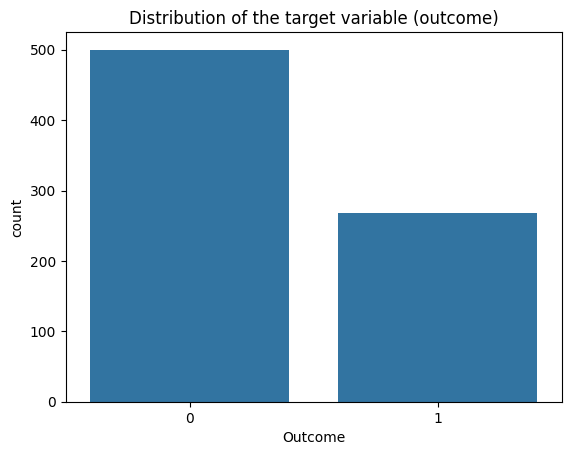

In [15]:
# 2. Distribution of the target variable
sns.countplot(x=y, data=df)
plt.title("Distribution of the target variable (outcome)")
plt.show()

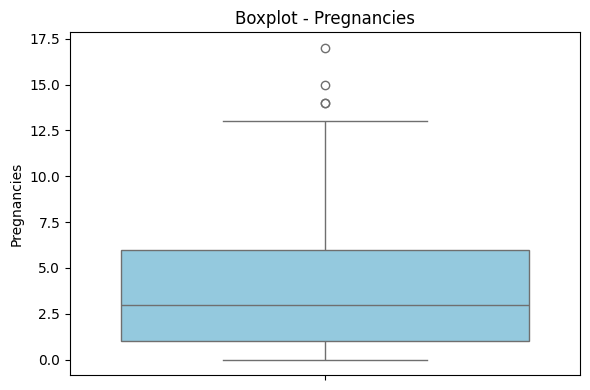

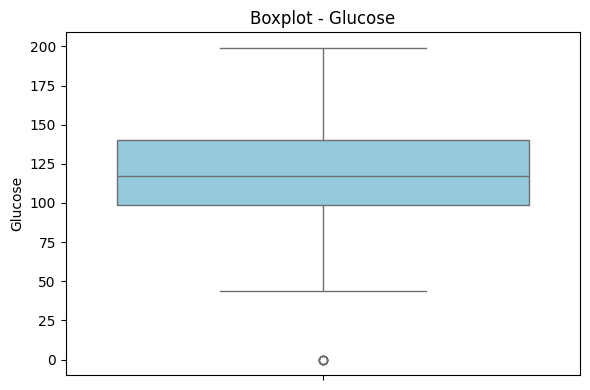

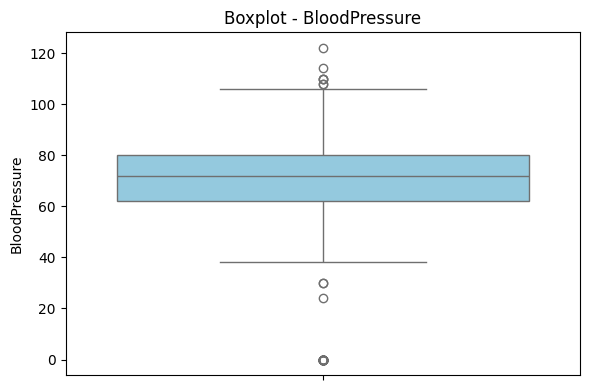

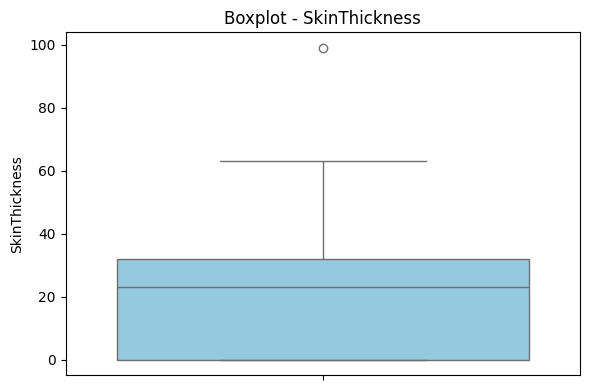

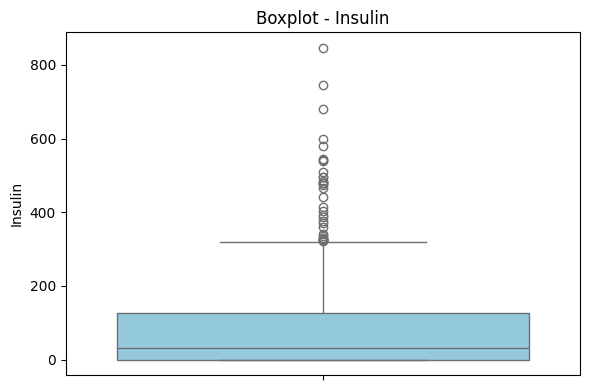

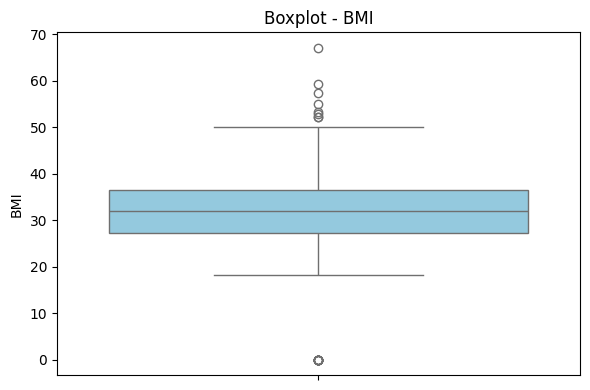

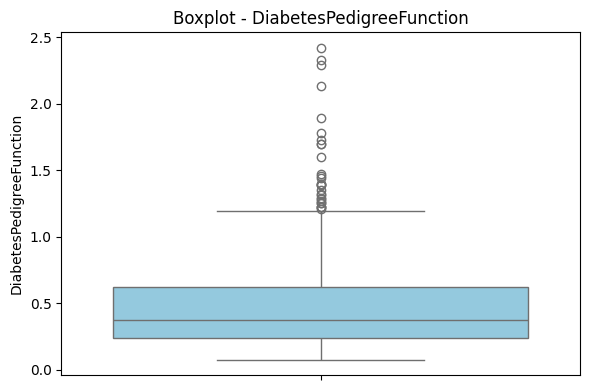

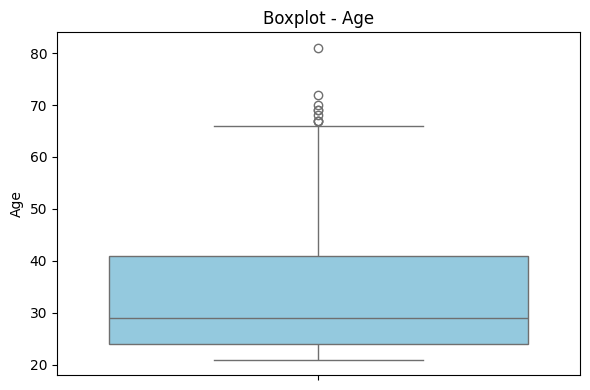

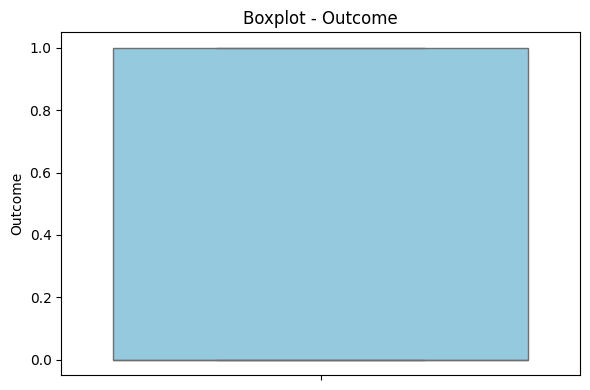

In [16]:
# 3.Boxplots to detect outliers
for col in name_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y = df[col], color="skyblue")
    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [17]:
def get_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers

for col in name_cols:
    outliers = get_outliers_iqr(df, col)
    print(f"Number of outliers: {len(outliers)}")
    if len(outliers) > 0:
        print("Index df",outliers[[col]].sort_values(col).to_string())

Number of outliers: 4
Index df      Pregnancies
298           14
455           14
88            15
159           17
Number of outliers: 5
Index df      Glucose
75         0
182        0
342        0
349        0
502        0
Number of outliers: 45
Index df      BloodPressure
7                0
703              0
426              0
430              0
435              0
453              0
468              0
484              0
494              0
522              0
533              0
535              0
589              0
601              0
604              0
619              0
643              0
697              0
347              0
336              0
357              0
300              0
15               0
49               0
60               0
78               0
81               0
332              0
172              0
706              0
193              0
222              0
261              0
266              0
269              0
597             24
125             30
18              30
36

In [26]:
def plotHistogram(values, label, feature, title):
    sns.set_style("whitegrid")
    plotOne = sns.FacetGrid(values, hue=label, aspect=2)
    plotOne.map(sns.histplot, feature)
    plotOne.set(xlim=(0, values[feature].max()))
    plotOne.add_legend()
    plotOne.set_axis_labels(feature, 'Proportion')
    plotOne.fig.suptitle(title)
    plt.show()

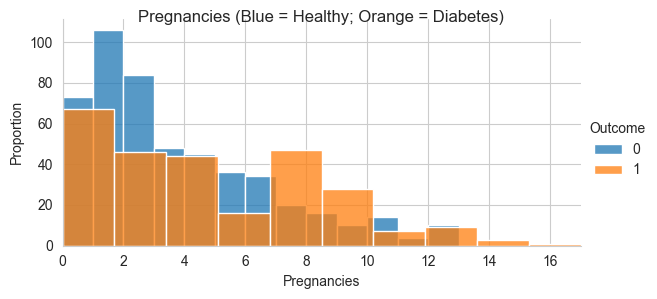

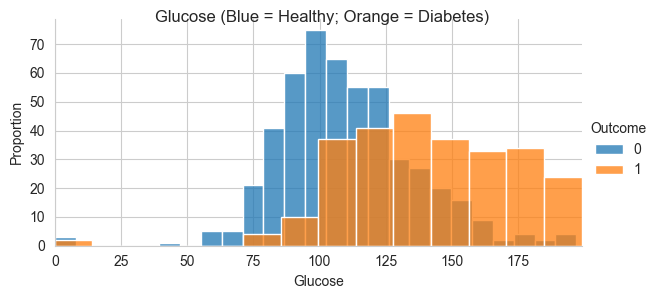

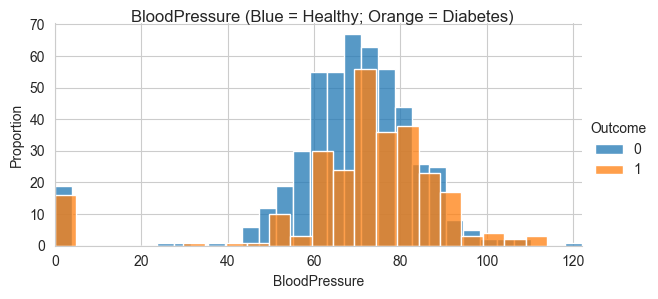

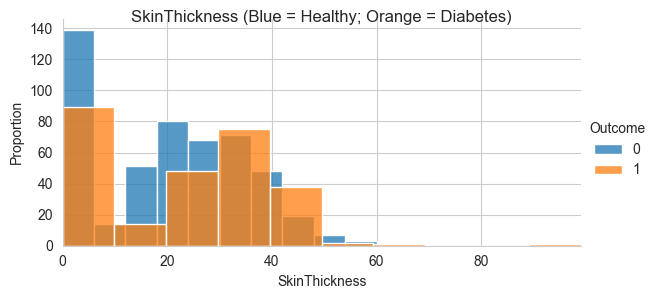

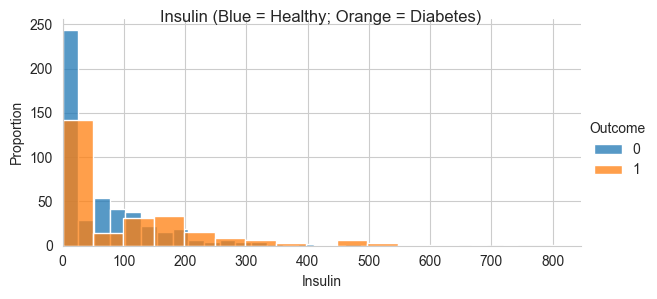

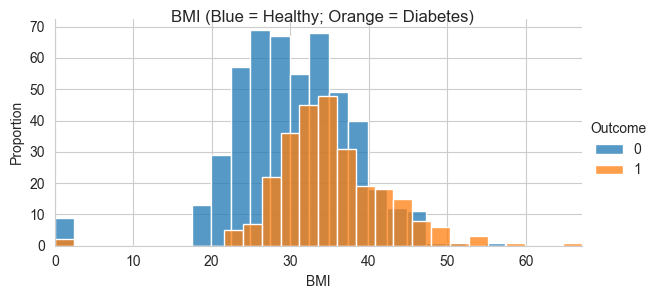

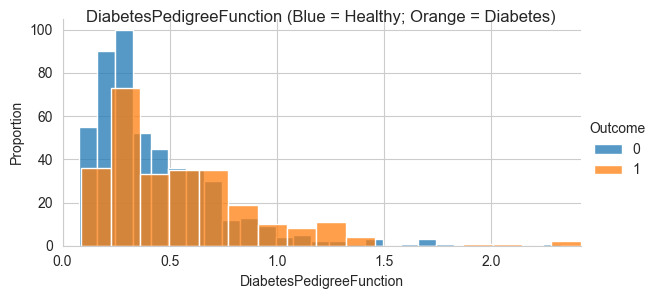

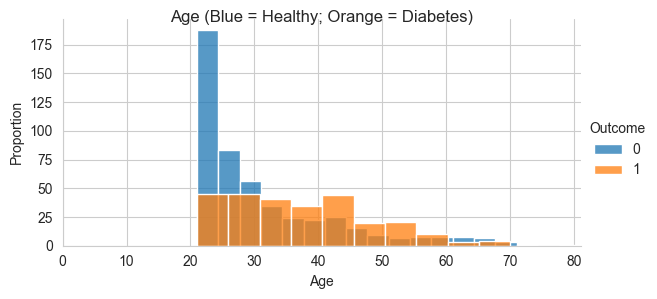

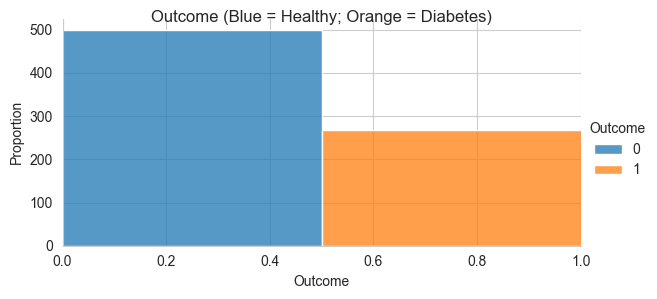

In [30]:
for col in name_cols:
    plotHistogram(df , target, col, f'{col} (Blue = Healthy; Orange = Diabetes)')

Data transformation

# 2. Feature selection

1. Filter methods: they evaluate each feature independently of the model, using statistical tests: MI, ANOVA, and correlation

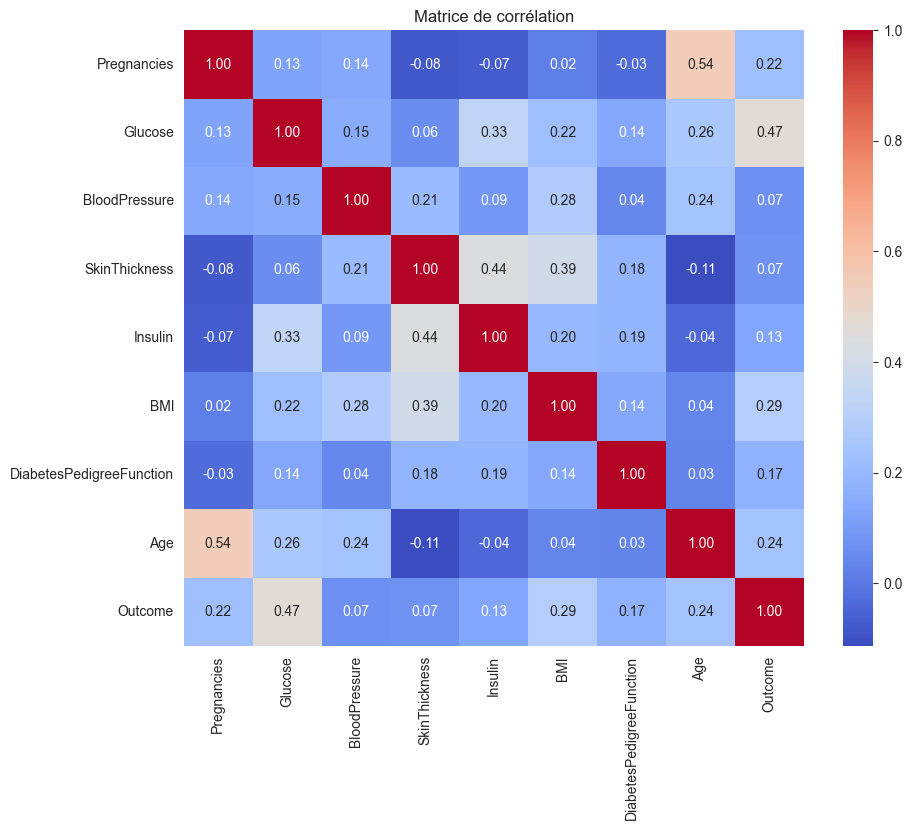

Corrélation de chaque feature avec la target

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [ ]:
# 1. Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Correlation of each feature with the targe
print("Correlation of each feature with the targe" + "\n")
print(corr["Outcome"].sort_values(ascending=False))

In [13]:
# 2. ANOVA F-test 

# Calculate F-scores and p-value
f_scores, p_values = f_classif(X, y)

# Sort by F-Score (from highest to lowest)
results = np.argsort(f_scores)[::-1]

# Display results
for i in results:
    print(f"{X.columns[i]}: F-score = {f_scores[i]:.4f},\
          p-value = {p_values[i]:.4f}")
    
# Si p < 0.05 → Différence significative (on rejette H₀)
# Si p ≥ 0.05 → Différence non significative (on garde H₀)

#UNE VARIABLE EST IMPORTANTE SI :
# p-value < 0.05 (significative)
# F-score élevé (grande variance entre groupes)

Glucose: F-score = 213.1618,          p-value = 0.0000
BMI: F-score = 71.7721,          p-value = 0.0000
Age: F-score = 46.1406,          p-value = 0.0000
Pregnancies: F-score = 39.6702,          p-value = 0.0000
DiabetesPedigreeFunction: F-score = 23.8713,          p-value = 0.0000
Insulin: F-score = 13.2811,          p-value = 0.0003
SkinThickness: F-score = 4.3044,          p-value = 0.0383
BloodPressure: F-score = 3.2570,          p-value = 0.0715


In [ ]:
# 3. Mutual Information

# Calculate MI for aLL columns
mi_scores = mutual_info_classif (X, y)

# Sort descending (highest to lowest)
sorted_indices = np.argsort(mi_scores)[::-1]  # descending order
for i in sorted_indices:
    print(f"{X.columns[i]}: MI = {mi_scores[i]:.4f}")

Glucose: MI = 0.1165
BMI: MI = 0.0761
Age: MI = 0.0668
Insulin: MI = 0.0498
BloodPressure: MI = 0.0342
SkinThickness: MI = 0.0194
DiabetesPedigreeFunction: MI = 0.0142
Pregnancies: MI = 0.0015


 2.  Méthodes embarquées (Embedded methods)

La sélection se fait pendant l'entraînement du modèle — souvent avec des modèles à base d'arbres ou de régularisation.

Feature importance avec Random Forest / XGBoost (le plus utilisé en pratique, vu qu'on en a parlé plus haut) :


In [22]:
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# rf.feature_importances_: gives a score for each feature, indicating how useful it was for reducing impurity (Gini) in the splits, averaged over the 200 trees.
# The SUM of all scores equals 1.

Glucose                     0.255198
BMI                         0.167063
Age                         0.136674
DiabetesPedigreeFunction    0.123510
BloodPressure               0.090281
Pregnancies                 0.084964
Insulin                     0.075432
SkinThickness               0.066878
dtype: float64


In [23]:
# 2. XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, random_state=42)
xgb_model.fit(X, y)
importances_XGBoost = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances_XGBoost)

Glucose                     0.255511
BMI                         0.148983
Age                         0.137409
DiabetesPedigreeFunction    0.101409
BloodPressure               0.097171
SkinThickness               0.095227
Pregnancies                 0.084984
Insulin                     0.079306
dtype: float32


In [24]:
# Based on the results from all methods:
# 'Insulin', 'Pregnancies', 'SkinThickness', 'BloodPressure', and 'DiabetesPedigreeFunction' are the 5 least important features.
# We will use the XGBoost results to save the list in the txt file.

list_feature_drop = list(importances_XGBoost.keys()[3:])[::-1]

In [25]:
# Save the list of the feature to drop in data_transformation
os.makedirs(os.path.dirname(config["data_transformation"]["list_feature_drop_file"]) or ".", exist_ok=True)
with open(config["data_transformation"]["list_feature_drop_file"], "w") as f:
    for element in list_feature_drop:
        f.write(str(element) + "\n")

# 3. Training

In [37]:
def search_false_positives_or_false_negatives_in_predictions (y_pred, y_test):

 y_test_arr = np.array(y_test).flatten()

 false_positives_idx = np.where((y_pred == 1) & (y_test_arr == 0))[0]  # False positives (predicted diabetic, but not)
 false_negatives_idx = np.where((y_pred == 0) & (y_test_arr == 1))[0]  # False negatives (predicted non-diabetic, but actually is)

 print(f"False positives (predicted diabetic, but not): {len(false_positives_idx)}")
 print(f"False negatives (predicted non-diabetic, but actually is): {len(false_negatives_idx)}")

In [38]:
def calculate_errors(y_pred, y_test):

 errors = np.abs(y_pred - y_test.values)
 n_errors = (errors == 1).sum()

 print(f"Number of errors: {n_errors} / {len(y_test)}")
 print(f"Error rate: {n_errors / len(y_test):.2%}")
 
 return errors, n_errors

1. Split data

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test, 80% train
    random_state=42     
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (614, 8), Test: (154, 8)


2. Training

2.1 XGBoost 

In [29]:
params = load_yaml_config('yaml file/params.yaml')
params

{'models': [{'model_name': 'XGBoost', 'params': {'n_estimators': 200}},
  {'model_name': 'SVM', 'params': {'C': 1, 'gamma': 0.04}},
  {'model_name': 'ANN',
   'params': {'epochs': 100,
    'batch_size': 4,
    'hidden_layer_sizes': '64, 32',
    'activation_hidden_layer': 'relu',
    'dropout_values': '0.5, 0.2',
    'l2': 0.1,
    'optimizer': 'Adam',
    'lr': 0.01}}]}

In [30]:
def XGBoost (X_train, X_test, n_estimators) :
    
    xgb_model = xgb.XGBClassifier(n_estimators = n_estimators, random_state=42)
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    errors, n_errors = calculate_errors(y_pred_xgb, y_test)
    
    return errors, n_errors 

In [31]:
def read_file(file_path):
    """Return the lines of a file"""
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            lines = file.readlines()
            lines = [item.rstrip('\n') for item in lines] # delete \n
            
            if not lines:
                print("❌ The file is empty")
                return
                
    except FileNotFoundError:
        print(f"❌ Error: The file '{file_path}' does not exist.")
    
    return lines    

In [32]:
list_feature_drop = read_file(config["data_transformation"]["list_feature_drop_file"])

In [33]:
# get n_estimators value from params.yaml
for item in params["models"]:
    if item['model_name'] == 'XGBoost':
        n_estimators = item['params']["n_estimators"]
        print(n_estimators)

200


In [39]:
drop_feature = []
error_rate = []

for i in range(len(list_feature_drop)):
    print("drop features", drop_feature)
    X_train_1 = X_train.drop(drop_feature, axis=1)
    X_test_1 = X_test.drop(drop_feature, axis=1)
    errors, n_errors = XGBoost (X_train_1, X_test_1, n_estimators)
    error_rate.append(n_errors)
    drop_feature.append(list_feature_drop[i])

drop features []
Number of errors: 45 / 154
Error rate: 29.22%
drop features ['Insulin']
Number of errors: 45 / 154
Error rate: 29.22%
drop features ['Insulin', 'Pregnancies']
Number of errors: 45 / 154
Error rate: 29.22%
drop features ['Insulin', 'Pregnancies', 'SkinThickness']
Number of errors: 41 / 154
Error rate: 26.62%
drop features ['Insulin', 'Pregnancies', 'SkinThickness', 'BloodPressure']
Number of errors: 42 / 154
Error rate: 27.27%


In [40]:
# Search for the minimum error rate and the features that were removed using XGBoost
min_index = np.argmin(error_rate)
print(f"The features removed using XGBoost correspond to the lowest error rate: {list_feature_drop[:min_index]}")

The features removed using XGBoost correspond to the lowest error rate: ['Insulin', 'Pregnancies', 'SkinThickness']


We drop 'Insulin', 'Pregnancies', 'SkinThickness features because Taux d'erreur moins for training SVM and ANN

In [41]:
X_train_1 = X_train.drop(drop_feature[:min_index], axis=1)
X_test_1 = X_test.drop(drop_feature[:min_index], axis=1)             

2.2 SVM

In [42]:
# get SVM params value from params.yaml
for item in params["models"]:
    if item['model_name'] == 'SVM':
       C = item['params']["C"]
       gamma = item['params']["gamma"]
       print("C value in params.yaml:", C)
       print("gamma value in params.yaml:", gamma)

C value in params.yaml: 1
gamma value in params.yaml: 0.04


In [43]:
# Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_1)
X_test_scaled = scaler.transform(X_test_1)  

svm_model = SVC(kernel="rbf", C=C, gamma=gamma, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
#print(classification_report(y_test, y_pred_svm))

calculate_errors(y_pred_svm, y_test)
search_false_positives_or_false_negatives_in_predictions(y_pred_svm, y_test)

Number of errors: 34 / 154
Error rate: 22.08%
False positives (predicted diabetic, but not): 15
False negatives (predicted non-diabetic, but actually is): 19


2.3 ANN 

In [44]:
# Split train data into train and validation sets
X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(
    X_train_1, y_train, test_size=0.10, random_state=42, stratify=y_train
)

print(f"Train: {X_train_2.shape}, Validation: {X_val_2.shape}, Test: {X_test_1.shape}")

Train: (552, 5), Validation: (62, 5), Test: (154, 5)


In [45]:
# Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2)
X_val_scaled = scaler.transform(X_val_2)
X_test_scaled = scaler.transform(X_test_1) 

In [46]:
# get ANN params value from params.yaml
for item in params["models"]:
    if item['model_name'] == 'ANN':
       epochs = item['params']["epochs"]
       batch_size = item['params']["batch_size"]
       hidden_layer_sizes = item['params']["hidden_layer_sizes"]
       hidden_layer_sizes = [int(x) for x in hidden_layer_sizes.split(',')]
       activation_hidden_layer = item['params']["activation_hidden_layer"]
       dropout_values = item['params']["dropout_values"]
       dropout_values = [float(x) for x in dropout_values.split(',')]
       l2 = item['params']["l2"]
       # Optimizer
       optimizer = item['params']["optimizer"]
       lr = item['params']["lr"] 

In [47]:
def ANN (hidden_layer_sizes, activation_hidden_layer, l2, dropout_values, optimizer,
         lr, epochs, batch_size, X_train_scaled, y_train_2,X_val_scaled, y_val_2):
    
 seed = 45
 random.seed(seed)
 np.random.seed(seed)
 tf.random.set_seed(seed)

 model_ANN = Sequential([
    Dense(hidden_layer_sizes[0], activation=activation_hidden_layer, kernel_regularizer=l2_reg(l2), input_shape=(X_train_scaled.shape[1],)),
    Dropout(dropout_values[0]),
    Dense(hidden_layer_sizes[1], activation=activation_hidden_layer, kernel_regularizer=l2_reg(l2)),
    Dropout(dropout_values[1]),
    Dense(1, activation='sigmoid')  # Binary output; for multi-class use softmax with n_class
 ])

 model_ANN.compile(
    optimizer=getattr(tf.keras.optimizers, optimizer)(learning_rate=lr),
    loss='binary_crossentropy',   # 'sparse_categorical_crossentropy' for multi-clas
    metrics=['accuracy']
 )

# Native early stopping, based on val_loss
 early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True 
 )

# Reduce LR by factor of 10 when validation loss plateaus
 reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,  # Divide by 10 (multiply by 0.1)
    patience=5,  # Wait 5 epochs before reducing
    min_lr=1e-7,  # Minimum learning rate
    verbose=1
 )

# Training
 history = model_ANN.fit(
    X_train_scaled, y_train_2,
    validation_data=(X_val_scaled, y_val_2),  
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=[early_stop, reduce_lr]
 )
 

# --- Plot loss train vs val ---
 best_epoch = len(history.history['loss']) - early_stop.patience
 epochs = range(1, len(history.history['loss']) + 1)
 plt.figure(figsize=(8, 5))
 plt.plot(epochs,history.history['loss'], label='Train loss')
 plt.plot(epochs, history.history['val_loss'], label='Validation loss')
 plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.7, 
            label=f'Meilleure epoch restaurée ({best_epoch})')
 plt.ylabel('Loss')
 plt.title('Train vs Validation Loss')
 plt.legend()
 plt.grid(True, alpha=0.3)
 plt.show()
 
 return model_ANN

Epoch 1/100
138/138 [==============================] - 2s 5ms/step - loss: 0.9913 - accuracy: 0.6594 - val_loss: 0.6505 - val_accuracy: 0.7097 - lr: 0.0100
Epoch 2/100
138/138 [==============================] - 0s 3ms/step - loss: 0.6531 - accuracy: 0.7011 - val_loss: 0.6174 - val_accuracy: 0.7097 - lr: 0.0100
Epoch 3/100
138/138 [==============================] - 0s 3ms/step - loss: 0.6394 - accuracy: 0.6938 - val_loss: 0.6511 - val_accuracy: 0.7742 - lr: 0.0100
Epoch 4/100
138/138 [==============================] - 0s 3ms/step - loss: 0.6453 - accuracy: 0.7083 - val_loss: 0.6055 - val_accuracy: 0.7581 - lr: 0.0100
Epoch 5/100
138/138 [==============================] - 0s 2ms/step - loss: 0.6297 - accuracy: 0.7138 - val_loss: 0.5851 - val_accuracy: 0.7903 - lr: 0.0100
Epoch 6/100
138/138 [==============================] - 0s 2ms/step - loss: 0.6368 - accuracy: 0.7138 - val_loss: 0.6119 - val_accuracy: 0.6935 - lr: 0.0100
Epoch 7/100
138/138 [==============================] - 0s 3ms/st

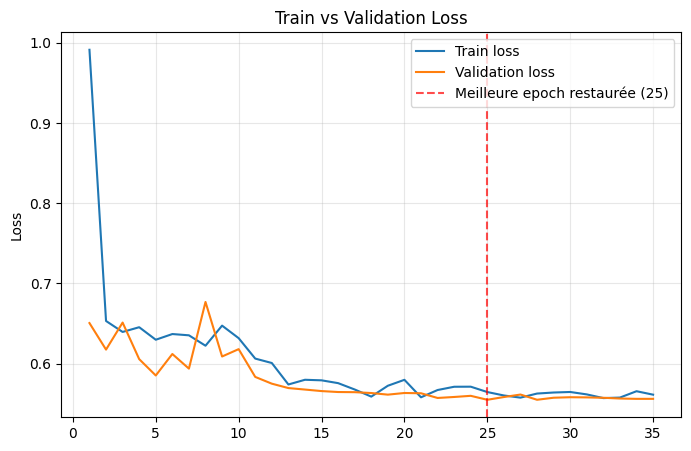

In [48]:
model_ANN = ANN(hidden_layer_sizes, activation_hidden_layer, l2, dropout_values, optimizer, lr, epochs, batch_size, X_train_scaled, y_train_2,X_val_scaled, y_val_2)

In [49]:
# Prediction 
y_pred_prob = model_ANN.predict(X_test_scaled,verbose=0)

# Conversion with threshold at 0.5 (standard)
y_pred_ANN = (y_pred_prob.flatten() > 0.5).astype(int)

# Evaluation
calculate_errors(y_pred_ANN, y_test)
search_false_positives_or_false_negatives_in_predictions(y_pred_ANN, y_test)
#print("")
#print(classification_report(y_test, y_pred_ANN))

Number of errors: 32 / 154
Error rate: 20.78%
False positives (predicted diabetic, but not): 11
False negatives (predicted non-diabetic, but actually is): 21


# 4. Predict new data (using ANN)

In [228]:
# save ANN model & scaler with joblib
joblib.dump (model_ANN, config["model_trainer"]["model_path"])
joblib.dump(scaler, config["model_trainer"]['scaler_path'])

['artifacts/model_trainer/scaler.joblib']

In [229]:
model_load = joblib.load(config["model_trainer"]['model_path'])
scaler_load = joblib.load(config["model_trainer"]['scaler_path'])

In [231]:
X_new_test = np.array([90, 52, 32, 0.4, 40])
X_new_test

array([90. , 52. , 32. ,  0.4, 40. ])

In [233]:
X_new_test_scaled = scaler_load.transform(X_new_test.reshape(1, -1))
X_new_test_scaled

X does not have valid feature names, but StandardScaler was fitted with feature names


array([[-0.94899581, -0.96316719, -0.00679194, -0.21290648,  0.63265044]])

In [234]:
y_pred_prob_new = model_load.predict(X_new_test_scaled,verbose=0)

In [ ]:
# Conversion with threshold at 0.5 (standard)
y_pred_new = (y_pred_prob_new.flatten() > 0.5).astype(int)
y_pred_new

array([0])

# 5. XAI (eXplainable AI)

5.1. SHAP (SHapley Additive exPlanations)

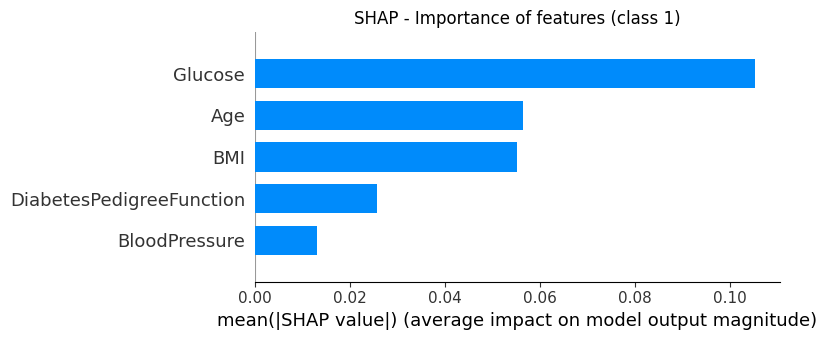

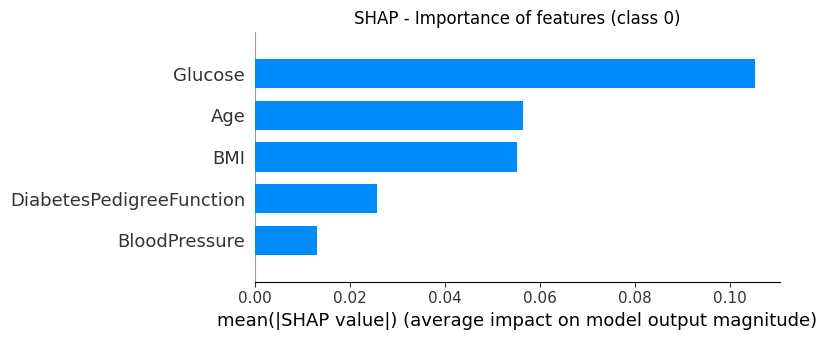

In [50]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

feature_names = list(X_train_2.columns)

# Create the explainer
explainer = shap.Explainer(lambda x: model_ANN.predict(x, verbose=0), X_train_scaled)

# Compute the SHAP values (for class 1, the model's native output)
shap_values = explainer(X_test_scaled, silent=True)

# --- Summary plot for class 1 ---
shap.summary_plot(
    shap_values,
    X_test_scaled,
    plot_type="bar",
    feature_names=feature_names,
    show=False
)
plt.title("SHAP - Importance of features (class 1)")
plt.tight_layout()
plt.show()

# --- Summary plot for class 0 (just with the opposite sign) ---
shap_values_class0 = shap.Explanation(
    values=-shap_values.values,          # opposite sign
    base_values=1 - shap_values.base_values,  # base_value is also inverted
    data=shap_values.data,
    feature_names=feature_names
)

shap.summary_plot(
    shap_values_class0,
    X_test_scaled,
    plot_type="bar",
    feature_names=feature_names,
    show=False
)
plt.title("SHAP - Importance of features (class 0)")
plt.tight_layout()
plt.show()

5.2 LIME (Local Interpretable Model-agnostic Explanations)

In [51]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

feature_names = list(X_train_2.columns)

# 1. Create the LIME explainer (on UNSCALED data).
explainer = LimeTabularExplainer(
    np.array(X_train_2),
    feature_names=feature_names ,
    class_names=['0', '1'],  # explain both classes
    mode='classification'
)

# 2. Prediction function that returns the PROBABILITIES for both classes
def predict_fn(x):
    x_scaled = scaler.transform(x)
    y_pred_prob = model_ANN.predict(x_scaled, verbose=0)  
    y_pred_prob = y_pred_prob.reshape(-1, 1)               # security to ensure shape (n, 1)
    return np.hstack([1 - y_pred_prob, y_pred_prob])       # shape (n, 2)

# 3. Generate explanations only once for all instances
all_explanations = []

for i in range(X_test_1.shape[0]):
    exp_i = explainer.explain_instance(
        np.array(X_test_1)[i, :],
        predict_fn,
        num_features=X_test_1.shape[1],
        labels=[0, 1]  
    )
    all_explanations.append(exp_i)

# 4. Function to display explanations for a given class
def display_importance_lime(number_class, all_explanations):
    feature_importance_agg = {}
    for exp_i in all_explanations:
        for feature, weight in exp_i.as_list(label=number_class):
            feature_importance_agg.setdefault(feature, []).append(weight)  

    mean_importance = {
        feature: np.mean(weights)
        for feature, weights in feature_importance_agg.items()
    }

    # Sort by magnitude, but keep the sign for color
    sorted_items = sorted(mean_importance.items(), key=lambda x: abs(x[1]), reverse=True)
    features, importance = zip(*sorted_items)
    colors = ['green' if v > 0 else 'red' for v in importance]

    plt.figure(figsize=(8, 5))
    plt.barh(features, importance, color=colors)
    plt.xlabel("Mean contribution")
    plt.title(f"Importance global of features (LIME) - class {number_class}")
    plt.axvline(0, color='gray', linestyle='--')
    plt.gca().invert_yaxis() 
    plt.tight_layout()
    plt.show()

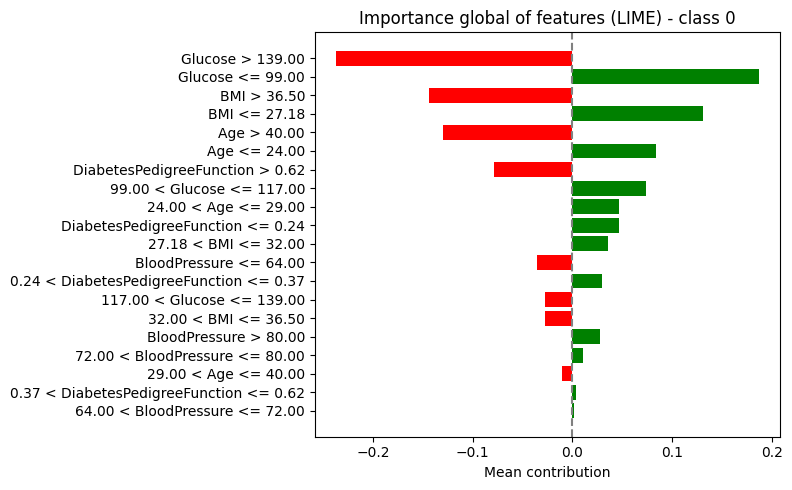

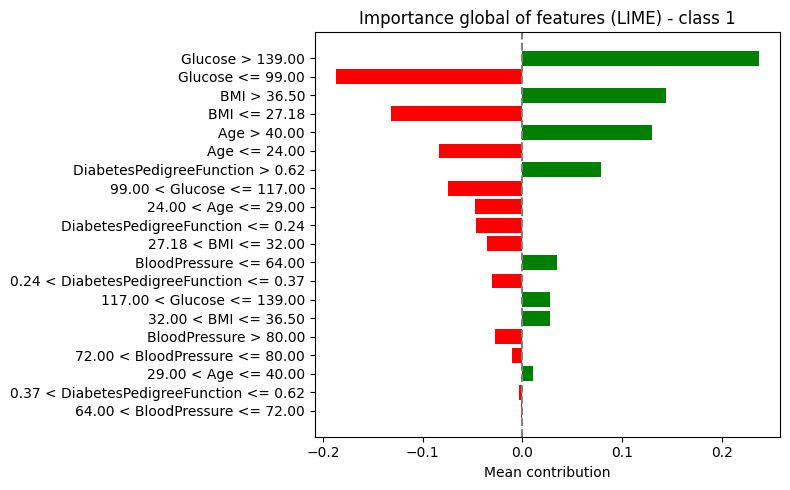

In [52]:
# 5. Display for both classes, using the same explanations already computed
display_importance_lime(0, all_explanations) 
display_importance_lime(1, all_explanations) # Class 1 (diabetic)

- POSITIVE weight: The feature increases the predicted probability of the requested class.

Example for label = 1 (diabetic): Glucose > 139 → weight = +0.42

This means: having high glucose increases the probability that the model predicts "class 1" (diabetic). The larger the weight, the stronger the effect.

- NEGATIVE weight: The feature lowers the predicted probability for the target class (it favors the opposite class).

For label = 1 (diabetic): Glucose <= 99 → weight = -0.35

Interpretation: low glucose values decrease the likelihood of class 1, effectively steering the prediction toward class 0 (non-diabetic).